# Vectors in 3-D — points, lines & polygons

Real **vector** GIS data from the Rhine basin (all EPSG:3035, metres), rendered in 3-D:

- **points** — gauges as a 3-D lollipop chart (height & colour by a model-error metric, MAE);
- **lines** — the river centerline as 3-D tubes;
- **polygons** — the basin outline extruded into a slab.

Geometry comes from the GeoDataFrame pyramids hands back; only coordinates are read (no GIS engine here — pyramids/cleopatra own that). Each is shown from a couple of viewpoints.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import geopandas as gpd

pv.OFF_SCREEN = True  # headless: scenes render to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title='', view='iso', parallel=False, zoom=None):
    """Point the camera at a named view, then screenshot the scene inline (asserts it isn't blank).

    view: 'iso' (oblique), 'top' (map/plan view), 'front', 'side', or an (azimuth, elevation) offset tuple
    applied on top of the isometric view. parallel=True uses an orthographic camera (true map scale).
    """
    p = scene.plotter
    if parallel:
        p.enable_parallel_projection()
    if view == 'top':
        p.view_xy()
    elif view == 'front':
        p.view_xz()
    elif view == 'side':
        p.view_yz()
    elif isinstance(view, tuple):
        p.view_isometric(); p.camera.azimuth += view[0]; p.camera.elevation += view[1]
    else:
        p.view_isometric()
    if zoom:
        p.camera.zoom(zoom)
    p.render()
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def lines_to_tubes(gdf, radius, z=0.0):
    """Turn a (Multi)LineString GeoDataFrame into a single tube mesh at height z (only coords read)."""
    tubes = []
    for geom in gdf.geometry:
        for part in (geom.geoms if geom.geom_type.startswith('Multi') else [geom]):
            xy = np.asarray(part.coords, dtype='float64')
            if len(xy) < 2:
                continue
            pts = np.column_stack([xy[:, 0], xy[:, 1], np.full(len(xy), z)])
            tubes.append(pv.lines_from_points(pts).tube(radius=radius))
    return pv.MultiBlock(tubes).combine()

def lollipops(gdf, value_col, height, radius):
    """Build vertical stems (a tube mesh) + top points (xyz, values) for a 3-D lollipop chart of point data."""
    x = gdf.geometry.x.to_numpy(); y = gdf.geometry.y.to_numpy()
    v = gdf[value_col].to_numpy(dtype='float64')
    z = v / np.nanmax(v) * height
    stems = [pv.Line((xi, yi, 0.0), (xi, yi, zi)).tube(radius=radius) for xi, yi, zi in zip(x, y, z)]
    return pv.MultiBlock(stems).combine(), np.column_stack([x, y, z]), v


## Point data — gauges as a 3-D lollipop chart

34 Rhine gauges carrying a hydrological-model error metric (mean absolute error, MAE). A stem rises to a height set by MAE, capped by a point coloured by the same value. Shown obliquely and from directly above.

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


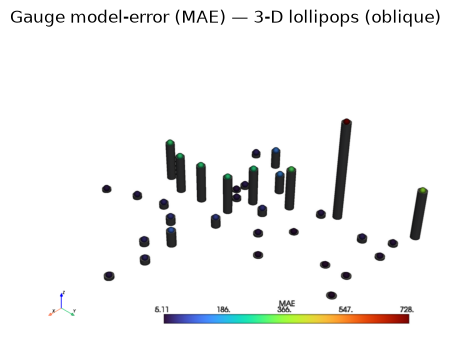

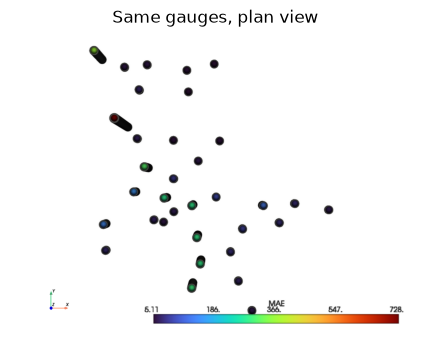

In [2]:
gauges = gpd.read_file(str(DATA / 'MetricsHM_Q_Obs.geojson')).dropna(subset=['MAE'])
stems, tops, vals = lollipops(gauges, 'MAE', height=140_000.0, radius=6_000.0)
scene = Scene3D(off_screen=True)
scene.add_mesh(stems, color='dimgray')
scene.point_cloud(tops, values=vals, point_size=38.0, cmap='turbo',
                  scalar_bar_args={'title': 'MAE'})
scene.plotter.add_axes()
show(scene, 'Gauge model-error (MAE) — 3-D lollipops (oblique)', view='iso', zoom=1.4)
show(scene, 'Same gauges, plan view', view='top', zoom=1.3)
scene.close()

## Line data — the river centerline as tubes

A `MultiLineString` of the Rhine network, turned into 3-D tubes. Tube radius is in CRS units (metres).

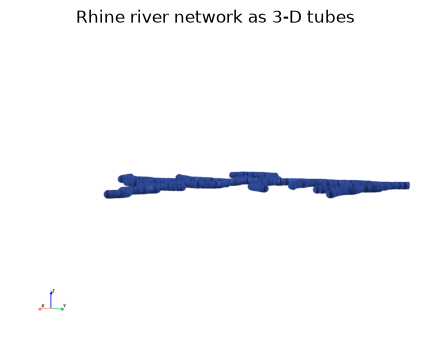

In [3]:
river = gpd.read_file(str(DATA / 'rhine_river_centerline.geojson'))
tubes = lines_to_tubes(river, radius=5_000.0)
scene = Scene3D(off_screen=True)
scene.add_mesh(tubes, color='royalblue')
scene.plotter.add_axes()
show(scene, 'Rhine river network as 3-D tubes', view=(0, -30), zoom=1.3)
scene.close()

## Polygon data — the basin extruded

The basin outline (`MultiPolygon`) extruded into a translucent slab with `extruded_polygons` — the footprint of the whole study area.

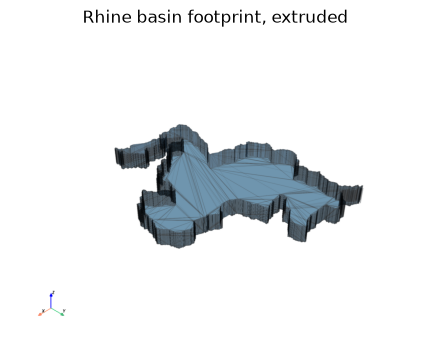

In [4]:
basin = gpd.read_file(str(DATA / 'rhine_basin.geojson'))
basin['thickness'] = 40_000.0
scene = Scene3D(off_screen=True)
scene.extruded_polygons(basin, height='thickness', color='steelblue',
                        opacity=0.5, show_edges=True, show_scalar_bar=False)
scene.plotter.add_axes()
show(scene, 'Rhine basin footprint, extruded', view='iso')
scene.close()

## All three vector layers in one scene

Basin slab + river tubes + gauge lollipops, stacked at different heights so each reads clearly. Shown obliquely and as an orthographic plan view.

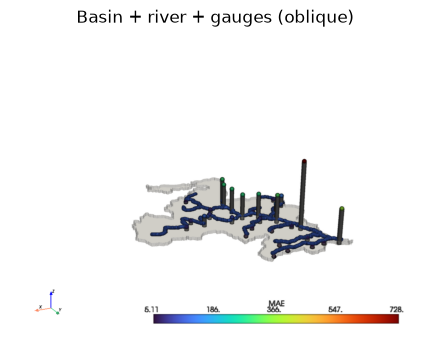

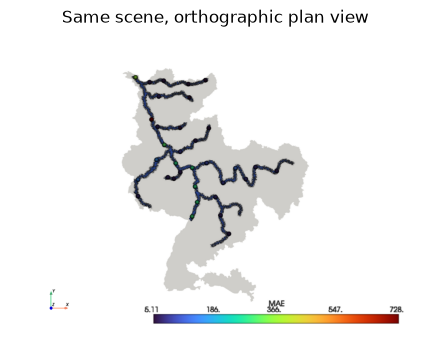

In [5]:
scene = Scene3D(off_screen=True)
basin['thickness'] = 8_000.0
scene.extruded_polygons(basin, height='thickness', color='gainsboro', opacity=0.35, show_scalar_bar=False)
scene.add_mesh(lines_to_tubes(river, radius=4_000.0, z=10_000.0), color='royalblue')
stems, tops, vals = lollipops(gauges, 'MAE', height=160_000.0, radius=5_000.0)
scene.add_mesh(stems, color='dimgray')
scene.point_cloud(tops, values=vals, point_size=26.0, cmap='turbo',
                  scalar_bar_args={'title': 'MAE'})
scene.plotter.add_axes()
show(scene, 'Basin + river + gauges (oblique)', view=(20, -15))
show(scene, 'Same scene, orthographic plan view', view='top', parallel=True)
scene.close()